In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Student_Performance.csv")

In [3]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [5]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [10]:
df=df.drop(df[["Extracurricular Activities"]],axis=1) #droping categorical column

In [11]:
df.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


In [12]:
x=df[["Hours Studied","Previous Scores","Sleep Hours","Sample Question Papers Practiced"]]
y=df["Performance Index"]

In [34]:
from sklearn.model_selection  import train_test_split
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [35]:
x_train

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced
9254,5,49,7,5
1561,2,48,7,6
1670,2,81,7,2
6087,2,46,6,1
6669,8,47,9,0
...,...,...,...,...
5734,8,50,6,6
5191,4,68,9,3
5390,9,48,7,6
860,1,47,9,0


In [36]:
df.shape

(10000, 5)

In [37]:
lr.fit(x_train,y_train)

LinearRegression()

In [38]:
lr.intercept_

np.float64(-33.60206732749278)

In [39]:
lr.coef_

array([2.85289351, 1.01703572, 0.47331832, 0.19172629])

In [40]:
y_pred=lr.predict(x_test)
y_pred

array([55.00786377, 22.31444624, 47.59404705, ..., 16.48182916,
       63.64243731, 46.23799491])

In [41]:
x_pred=lr.predict(x_train)

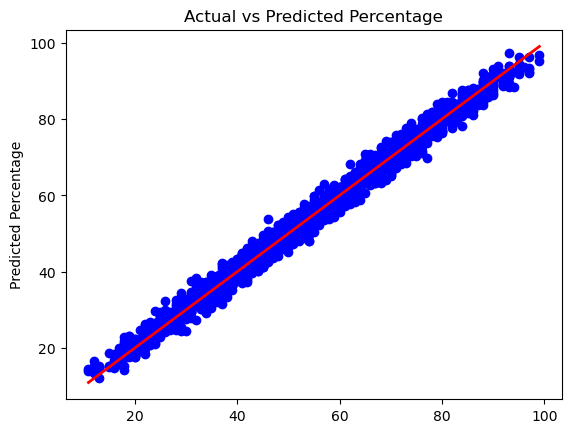

In [42]:
# Plot actual vs predicted values
plt.scatter(y_test, y_pred, color='blue') 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) 
plt.ylabel("Predicted Percentage")
plt.title("Actual vs Predicted Percentage")
plt.show()

In [44]:
from sklearn.metrics import r2_score,mean_absolute_error
r2=r2_score(y_test,y_pred)
r2 #accuracy 98.8%

0.9887144552384186

In [50]:
mae=mean_absolute_error(y_test,y_pred)
mae

1.6296726874197032

In [47]:
from sklearn.metrics import root_mean_squared_error
#root mean squared error
rmse=root_mean_squared_error(y_test,y_pred)
rmse  # if more accurate then rmse is small

2.045056213064527

In [49]:
from sklearn.metrics import mean_squared_error
# mean squared error
mse=mean_squared_error(y_test,y_pred)
mse

4.182254914593825